<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/gymnasium/001-solving-cartpole_v1-with-reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving CartPole-v1 with REINFORCE

This notebook solves the [Gymnasium CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment using **REINFORCE** (aka Vanilla Policy Gradient). **REINFORCE** is:

- **Policy-based:** Learns a policy directly, unlike value-based methods (eg: **DQN**) that learn a value function and derive a policy from it.
- **On-policy:** The policy being learned is the one interacting with the environment.
- **Model-free:** Requires no knowledge of environment dynamics, such as predicting next states or rewards.
- **Monte Carlo:** Updates the policy at episode's end, unlike **Temporal Difference (TD)** methods that update after one or more steps.

## Setup

First, let's install the stuff we'll need:

In [70]:
!pip install gymnasium # The gymnasium environment
!pip install tsilva-notebook-utils # Personal utils to help with notebook authoring

Here are the key settings we'll use. Don't worry about their meanings just yet—you can experiment with them later, once you've completed the notebook, to see if you can further improve your results.

In [71]:
ENVIRONMENT_ID = "CartPole-v1" # The environment we want to solve
DISCOUNT_FACTOR = 0.99  # Discount factor controls how much we value future rewards
HIDDEN_SIZE = 128  # Neural network hidden layer size (128 gives enough capacity without overfitting)
LEARNING_RATE = 0.002  # Learning rate for optimizer (0.002 is a safe middle ground for small networks)
N_TRAIN_EPISODES = 5_000  # Total training episodes (5k should be more than enough)
AVERAGE_REWARD_WINDOW = 50  # Episodes required for calculating average reward
AVERAGE_REWARD_THRESHOLD = 500  # Average reward required to consider environment as solved

## Inspect Environment

Let's set up the environment and peek at it:

In [72]:
import gymnasium as gym
env = gym.make(ENVIRONMENT_ID, render_mode="rgb_array")
env.observation_space.shape, env.action_space

((4,), Discrete(2))

Observations (aka states) are `4` numbers, and actions are just `0` or `1`. The [docs](https://gymnasium.farama.org/environments/classic_control/cart_pole/) explain what those numbers mean, but honestly, we don't need to care, the reinforcement learning algorithm will be able to solve the environment regardless.

Let's run the environment for one episode with a random policy to see how it looks like:

In [73]:
import numpy as np
from tsilva_notebook_utils.video import render_video

# Define random policy
policy = lambda state: env.action_space.sample()

# Reset environment
state, _ = env.reset()

# Run environment step by step until
# it communicates it has finished
rewards = []
frames = []
done = False
while not done:
    # Render current state and collect frame
    frame = env.render()
    frames.append(frame)

    # Get next action from policy
    action = policy(state)

    # Execute action in environment
    next_state, reward, terminated, truncated, _ = env.step(action)

    # Determine if the environment
    # has finished (eg: pole fell,
    # cartpole went off the screen)
    done = terminated or truncated
    state = next_state

    # Collect reward
    rewards.append(reward)

# Log total reward
print(f"Sample rewards: {rewards[:5] + rewards[:-5]}")
print(f"Total Reward: {np.array(rewards).sum()}")

# Render collected environment frames as video
render_video(frames)

Sample rewards: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Total Reward: 57.0


Spoiler: it's bad. The pole falls quickly because random actions aren't enough. You receive a `1.0` reward per step until it crashes, and to win, you need to last **500** steps. Now that we've seen how poorly a random policy performs, let's explore how **REINFORCE** can train a much smarter one.

## Intuitions on REINFORCE

Imagine you're playing **rock-paper-scissors** against a friend. Each round, you pick **rock, paper, or scissors** based on their last move. Say they just played **rock**—that's your **state**—and you've got confidence levels:  

- **50%** for paper  
- **30%** for rock  
- **20%** for scissors  

You choose one, they play again, and you score:  

- **+1** if you win  
- **0** if it's a tie  
- **-1** if you lose  

You play **5 hands** and add up the total—maybe **+2** if you win twice, tie once, and lose twice. **REINFORCE** takes that final score to tweak your instincts for next time, even though it's not certain every choice was ideal.  

If your total is **+2**, you look back at each move and think, *“These picks probably helped.”* Say after they played **rock**, you chose **paper** with **50% confidence**—since the episode went well, you boost that a bit, like, *“That paid off, lean into it more.”* If after they played **scissors**, you picked **rock** at **70%**, you nudge it up less—you were already on track. If the total is **-3**, you dial down shaky choices more—like a **20% confidence in scissors**—and confident ones less.  

Your friend isn't playing randomly—they have biases:  

- They might **lean toward rock after winning**  
- They might **repeat scissors when nervous**  

You don't know exactly which moves helped each time, but that final score hints: *"I did well, so these were smart guesses."* It's a bet that **raising confidence** for high-scoring rounds and **lowering it** for low ones will sharpen your instincts. Over many games, you pick up on their habits—like playing **paper more often after showing rock**—and your scores steadily improve. **REINFORCE** acts as a guide, refining your choices hand by hand, turning hunches into a strategy that **exploits their quirks**.

## Create Policy Model

To train a policy with **REINFORCE**, we need a model that can be easily adjusted based on how well the policy performed (i.e., the episode's reward). **Neural Networks**, combined with **Backpropagation** and **Gradient Descent**, are ideal for this. As long as we define a loss function that increases when the policy performs poorly, these techniques will adjust the model’s parameters to reinforce good actions and reduce the likelihood of bad ones in future episodes.

Let's create the **Neural Network** that will represent our policy:

In [74]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()

        # Create a multilayer perceptron with just one hidden layer
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE), # Hidden layer (observation_space_size, hidden_layer_size)
            nn.ReLU(), # ReLU activation (for be able to model a non-linear functions)
            nn.Linear(HIDDEN_SIZE, action_dim) # Output layer (hidden_layer_size, action_space_size)
        )

    def forward(self, x):
        return self.net(x)

input_size = env.observation_space.shape[0]
output_size = env.action_space.n
model = PolicyNetwork(input_size, output_size)
model

PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

This environment has a low-dimensional continuous observation space and a small discrete action space, so our **Neural Network** can be a simple **Multilayer Perceptron** with just one hidden layer.  

It takes **4** observation values as input and outputs **2** numbers (logits), representing how good each action is in a given state.  

Let's test it by running an observation through the network:

In [75]:
with torch.no_grad(): # Don't track gradients during inference
  action_logits = model(torch.tensor(state)) # State is a numpy object, needs to be converted to tensor first
action_logits

tensor([ 0.3547, -0.2088])

The higher the logit corresponding to an action, the more confident the model is that action should be taken when in that state. But since the model hasn't been trained yet, these logits are pretty much random right now.

Logits alone aren’t ideal for our needs. While they can indicate the "best" action to take, we don’t always want to pick the highest-scoring action—especially since the model doesn’t initially know which actions are truly the best. Instead, we want to **sample** from the possible actions, favoring those the model is more confident in.  

This approach balances **exploration and exploitation**:  
- It allows the model to occasionally try less-favored actions, which might lead to **unexpectedly high rewards** and further learning.  
- It also ensures that the model **leans toward the best-known actions** while still refining its understanding over time.

In order to sample the actions according to the confidence assigned by the model, we need to convert the logits into a probability distribution (values ranging from `0.0` to `1.0` with values summing to `1.0`)by applying the `softmax()` on them:

In [76]:
action_probs = torch.softmax(action_logits, dim=-1) # Dim = -1 means the last dimension of the tensor, Dim = 0 would also work in this case
action_probs, action_probs.sum()

(tensor([0.6373, 0.3627]), tensor(1.0000))

Let's now sample an action:

In [77]:
action = torch.multinomial(action_probs, 1).item() # Sample 1 action from the probability distribution
action

1

You can run the cell above multiple times, and get different actions each time. The action associated with the highest logit will appear more frequently, as expected.

## Model the Loss Function

When training a policy with **REINFORCE**, the policy loss shapes action choice improvements.  

We need to design a **loss function** that optimizes **episode rewards** while simultaneously promoting **confident and accurate predictions**. It should:  

- **Encourage** high-confidence **correct** predictions  
- **Penalize** high-confidence **incorrect** predictions  
- **Penalize** low-confidence **correct** predictions  

Picture yourself back in that **rock-paper-scissors** game we talked about—playing against your friend with their quirky biases, picking **rock, paper, or scissors** based on their last move. Say they just played **rock**, and your confidence levels are:  

- **50%** for paper  
- **30%** for rock  
- **20%** for scissors  

You play **five hands** and tally the score—maybe **+2** from a couple of wins. Sweet! If you were **90% sure** of “paper” after their rock and won, it's like, *“Yes, lock that in next time.”* But if you barely trusted “scissors”—only **10% sure**—after their paper and still pulled it off, it's more like, *“Nice, but that was a fluke; don’t get too excited.”*  

Now, if you end up with **-3**, a smug **90% confidence in “rock”** that failed gets a bigger *“seriously?”* than a shaky **10% confidence in “paper”** that lost. We're tuning your gut based on that final score—boosting the good, cutting the bad, then flipping it so our optimizer knows what to chase.  

Let's design the loss function step-by-step:

**Step 1: Compute Returns**

To construct the loss function, we first need to compute the return for each step, which consists of the immediate reward plus discounted future rewards. Since future rewards are uncertain, their influence should diminish over time, with more distant rewards contributing less to the total return.

**Step 2: Normalize**

Next, we normalize these returns by subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$. Normalization keeps training stable by focusing on relative performance, not absolute reward scales, which can vary wildly between episodes.

**Step 3: Scale with Log Probs**

We then scale returns by the policy's confidence using the logarithm of probabilities, $\log \pi(a|s)$, rather than raw probabilities. Logarithms amplify small confidence differences—low-confidence actions yield large negative logs, tempering flukes—while aiding optimization smoothness. Here's how it works:

- **Big return, high confidence:** Raw return `100` normalizes to `+2`, with `90%` confidence ($\log(0.9) \approx -0.1$). Loss term: $+2 \times -0.1 = -0.2$. The policy gets a small nudge, reinforcing this trusted action since the reward aligns with high confidence.
- **Big return, low confidence:** Raw return `100` normalizes to `+2`, with `0.1%` confidence ($\log(0.001) \approx -6.9$). Term: $+2 \times -6.9 = -13.8$. The large negative log dims this fluke's impact, preventing overreaction to a rarely chosen action.
- **Bad return, low confidence:** Raw return `-50` normalizes to `-1`, confidence `0.1%` ($\log(0.001) \approx -6.9$). Term: $-1 \times -6.9 = +6.9$. The update is small, fitting the action's rarity—no big shift for a one-off misstep.
- **Bad return, high confidence:** Raw return `-50` normalizes to `-1`, confidence `90%` ($\log(0.9) \approx -0.1$). Term: $-1 \times -0.1 = +0.1$. The policy adjusts more, rethinking a trusted action that led to a poor outcome.


**Step 4: Calculate the Loss**

Finally after scaling down the returns, we can calculate the mean of all returns. This is the number we want our policy to maximize. But since **Gradient Descent** is the optimization process typically used in **Neural Networks**, we negate this value, such that when it reaches its maximum value, the loss is a negative number with very high magnitude.

Now that we know how to build our loss function, let's do it step by step. First we need to collect the rewards and action log probabilities for an episode:

In [78]:
def run_episode(env, policy, train_mode=False):
    # Reset the environment
    state, _ = env.reset()

    # Run environment until it
    # communicates that it has finished
    done = False
    rewards = []
    action_logprobs = []
    frames = []
    while not done:
        # Render frame
        frame = env.render()
        frames.append(frame)

        # Predict action probabilities using the model
        with torch.no_grad() if not train_mode else torch.enable_grad():
            action_logits = policy(torch.tensor(state))
            action_probs = torch.softmax(action_logits, dim=-1)
            action = torch.multinomial(action_probs, 1).item()

        # Collect action log probabilities
        action_prob = action_probs[action]
        action_log_prob = torch.log(action_prob)
        action_logprobs.append(action_log_prob)

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store reward and update state
        rewards.append(reward)
        state = next_state

    return rewards, action_logprobs, frames

# Run an episode
rewards, action_logprobs, _ = run_episode(env, model)
rewards[:5], action_logprobs[:5]

([1.0, 1.0, 1.0, 1.0, 1.0],
 [tensor(-0.5908),
  tensor(-0.5656),
  tensor(-0.8682),
  tensor(-0.5645),
  tensor(-0.5434)])

Now we can calculate the returns for each step (let's not normalize them just yet):

In [79]:
def calculate_returns(rewards, discount_factor=DISCOUNT_FACTOR, normalize=True):
    # Initialize returns tensor (same shape as rewards)
    returns = torch.zeros(len(rewards))

    # Return for each step is the reward for that step
    # plus the discounted return for the next step
    # (calculated from last to first step)
    for t in range(len(returns)-1, -1, -1):
      returns[t] = rewards[t] + discount_factor * (returns[t+1] if t < len(returns)-1 else 0)

    # To normalize values so that they match a normal distribution
    # we only have to subtract the mean of the values and divide by
    # the standard deviation
    if normalize: returns = (returns - returns.mean()) / (returns.std() + 1e-8) # NOTE: we add a small value to std() because it can be zero when all values are the same

    # Return the returns :)
    return returns

calculate_returns(rewards, normalize=False)

tensor([10.4662,  9.5618,  8.6483,  7.7255,  6.7935,  5.8520,  4.9010,  3.9404,
         2.9701,  1.9900,  1.0000])

As shown above, earlier timesteps yield higher returns since they account for the discounted rewards of all future steps. Conversely, returns decrease as the episode progresses, ultimately reaching `1.0` at the final step, which reflects only the immediate reward received at that moment.  

However, it's important to note that this pattern of diminishing returns across the episode may not always be linear. In this simple environment, where each step consistently grants an immediate reward of `1.0`, the progression is straightforward. In more complex environments, where rewards vary in magnitude and polarity—being large or small, positive or negative—the return dynamics would differ significantly.

Now let's calculate the returns again, but this time with normalization:

In [80]:
returns = calculate_returns(rewards)
returns

tensor([ 1.4849,  1.1968,  0.9058,  0.6119,  0.3150,  0.0151, -0.2878, -0.5937,
        -0.9028, -1.2150, -1.5303])

Don't worry about the negative numbers because the relative scale of the rewards is intact, and that's all that matters. It's the direction of the return that matters, not the sign.

Now, we need to ensure that the action log probabilities are in the same format as the returns—a 1D tensor of the same length. Currently, they are stored as a list of tensors, as shown above. We can convert them into a single tensor by concatenating them using `torch.stack()`:

In [81]:
stacked_action_logprobs = torch.stack(action_logprobs)
stacked_action_logprobs

tensor([-0.5908, -0.5656, -0.8682, -0.5645, -0.5434, -0.5197, -0.9398, -0.5165,
        -0.4907, -0.4674, -1.0157])

Let's confirm that both **returns** and **action log probabilities** have the same shape:

In [82]:
returns.shape, stacked_action_logprobs.shape

(torch.Size([11]), torch.Size([11]))

They are both the same shape, so we can now use them to scale the returns:

In [83]:
scaled_returns = stacked_action_logprobs * returns
scaled_returns

tensor([-0.8773, -0.6769, -0.7864, -0.3454, -0.1712, -0.0079,  0.2704,  0.3067,
         0.4430,  0.5679,  1.5543])

With the returns scaled, we can now calculate the mean return for the episode, which is the value we want our policy to maximize:

In [84]:
mean_return = torch.mean(scaled_returns)
mean_return

tensor(0.0252)

And finally, we just need to negate the mean return to get the policy loss (remember that **gradient descent** wants to make the loss as small as possible and that must correlate with our policy being better, so by negating the mean return, we create a term that when minimized, improves the mean return):

In [85]:
policy_loss = -1.0 * mean_return
policy_loss

tensor(-0.0252)

Let's encapsulate all this work in a loss calculation function that we can use during training:

In [86]:
def calculate_policy_loss(rewards, action_logprobs):
    returns = calculate_returns(rewards)
    stacked_action_logprobs = torch.stack(action_logprobs)
    scaled_returns = stacked_action_logprobs * returns
    mean_return = torch.mean(scaled_returns)
    policy_loss = -mean_return
    return policy_loss

calculate_policy_loss(rewards, action_logprobs)

tensor(-0.0252)

Now that we know how to calculate the loss our work is done, it's time to put everything together and run the training loop and adjust the policy based on that loss using backpropgation and gradient descent optimization.

## Train Policy

In [87]:
import time
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tsilva_notebook_utils.video import render_video

def train(model, n_episodes=N_TRAIN_EPISODES):
  # Set the model in training mode
  model.train()

  # Create the optimizer that will adjust the policy
  # model's parameters to minimize policy loss
  optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

  # Run training for N episodes
  start = time.time()
  episode_rewards = []
  for episode in range(N_TRAIN_EPISODES):
      # Run the episode (enable train mode to track gradients)
      rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)

      # Calculate the policy loss
      policy_loss = calculate_policy_loss(rewards, action_logprobs)

      # Zero out the gradients (otherwise they would
      # accumulate between optimization steps)
      optimizer.zero_grad()

      # Perform backpropagation to calculate policy model
      # parameter gradients, which inform on how to tweak
      # parameters to reduce loss, capturing both direction and scale
      policy_loss.backward()

      # Perform an optimization step, using gradients calculated
      # during backpropagation to adjust model parameters in the direction
      # that is likely to make the loss smaller (adjustment is scaled
      # down by magnitude of learning rate)
      optimizer.step()

      # Store total reward to plot at end of training
      total_reward = np.array(rewards).sum()
      episode_rewards.append(total_reward)

      # Every N episodes, calculate the average reward of those episodes,
      # if it passes a threshold, the environment is considered to be solved
      # (NOTE: we need to make sure the average is above the threshold to
      # discount for episodes where the policy was just lucky)
      if (episode + 1) % AVERAGE_REWARD_WINDOW == 0:
          avg_reward = np.mean(episode_rewards[-AVERAGE_REWARD_WINDOW:])
          print(f"Episode {episode + 1}, Avg Reward: {avg_reward}")
          if avg_reward >= AVERAGE_REWARD_THRESHOLD:
              break

  # Close environment
  env.close()

  # Print final stats
  elapsed = time.time() - start
  print(f"Environment solved in {episode} episodes ({elapsed:.2f} seconds)")

  return episode_rewards

# Train the policy model
episode_rewards = train(model)
episode_rewards[:5] + ["..."] + episode_rewards[-5:]

Episode 50, Avg Reward: 20.7
Episode 100, Avg Reward: 29.72
Episode 150, Avg Reward: 45.76
Episode 200, Avg Reward: 115.4
Episode 250, Avg Reward: 177.04
Episode 300, Avg Reward: 240.02
Episode 350, Avg Reward: 312.26
Episode 400, Avg Reward: 370.48
Episode 450, Avg Reward: 396.2
Episode 500, Avg Reward: 442.28
Episode 550, Avg Reward: 452.02
Episode 600, Avg Reward: 471.44
Episode 650, Avg Reward: 462.12
Episode 700, Avg Reward: 482.84
Episode 750, Avg Reward: 485.44
Episode 800, Avg Reward: 500.0
Environment solved in 799 episodes (1132.67 seconds)


[16.0, 30.0, 18.0, 22.0, 30.0, '...', 500.0, 500.0, 500.0, 500.0, 500.0]

Our model is trained, let's plot how training progressed:

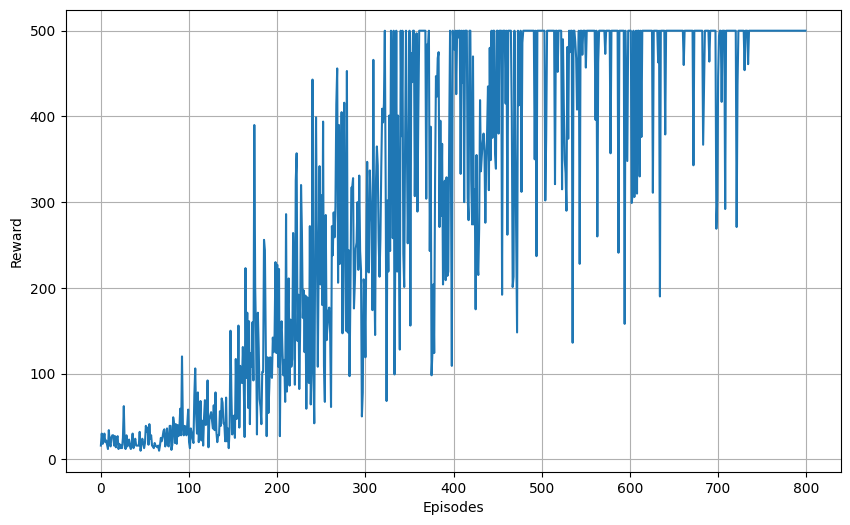

In [88]:
def plot_episode_rewards(episode_rewards):
  plt.figure(figsize=(10, 6))
  plt.xlabel('Episodes')
  plt.ylabel('Reward')
  plt.grid(True)
  plt.plot(episode_rewards)
  plt.show()

plot_episode_rewards(episode_rewards)

We stopped as soon as we reached our reward threshold due to the inherent instability of the training process. If we had continued, the policy might have started exploring suboptimal behaviors, potentially degrading its performance. To train for longer periods while avoiding this issue, we should periodically save snapshots of the model's parameters whenever a new best reward is achieved. This way, we can revert to the best-performing version when training concludes.

## Evaluate Policy

Just getting the a good reward during training is not enough, the real test is to run the trained policy on the environment multiple times and check the consistency of rewards it receives, if you average those out, that's the true measure of how good the policy is:

In [89]:
from IPython.display import clear_output

def evaluate(model, n_episodes=10):
    # Set the model in evaluation mode
    model.eval()

    # Run evaluation for N episodes
    episode_rewards = []
    for episode in range(n_episodes):
        rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)
        episode_reward = np.array(rewards).sum()
        episode_rewards.append(episode_reward)
        print(f"Episode {episode+1} Reward: {episode_reward}")

    # Print final stats
    mean_reward = np.mean(episode_rewards)
    print(f"Mean reward over {n_episodes} episodes: {mean_reward}")

    # Return stats and frames (for rendering)
    return mean_reward, frames

_, frames = evaluate(model, n_episodes=10)
render_video(frames)

Episode 1 Reward: 500.0
Episode 2 Reward: 500.0
Episode 3 Reward: 500.0
Episode 4 Reward: 500.0
Episode 5 Reward: 500.0
Episode 6 Reward: 500.0
Episode 7 Reward: 500.0
Episode 8 Reward: 500.0
Episode 9 Reward: 500.0
Episode 10 Reward: 500.0
Mean reward over 10 episodes: 500.0


## Further Improvements

And we're done! If you want to try squeezing more juice out of the algorithm consider running these experiments:

- **Crank up `LEARNING_RATE`**: Set it to `0.01` and see if training speeds up—run it and watch the rewards climb faster!
- **Dial down `LEARNING_RATE`**: Drop it to `0.001` for more careful updates—check how it steadies the learning curve.
- **Adjust `DISCOUNT_FACTOR`**: Try `0.95` to care more about short-term rewards—plot it and see the difference!
- **Boost `HIDDEN_SIZE`**: Pump it to `256` for a beefier network—test if it handles the pole better.
- **Add a baseline**: Grab the average return from past episodes and subtract it from `returns` before scaling—it'll cut the chaos and smooth things out. Give it a go!
- **Try different environment**: Try running this codebase on a different environment with similar characteristics, such as:
 - [Acrobot-v1](https://gymnasium.farama.org/environments/classic_control/acrobot/)
 - [MountainCar-v0](https://www.gymlibrary.dev/environments/classic_control/mountain_car/)
 - [LunarLander-v2](https://www.gymlibrary.dev/environments/box2d/lunar_lander/)
 - [Blackjack-v1](https://www.gymlibrary.dev/environments/toy_text/blackjack/)
 - [FrozenLake-v1](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/)

Tweak these one by one, rerun the code, and find your winning combo!
